# Mutual Fund Capstone Project: Exploratory Data Analysis (EDA)

This notebook performs a deep exploratory data analysis (EDA) on the mutual fund datasets stored in `bluestock_mf.db`. It visualizes trends in Net Asset Value (NAV), Assets Under Management (AUM), Systematic Investment Plans (SIP) inflows, category-level dynamics, investor demographics, and geographic distributions.

## Day 3 Deliverables:
- 16 Publication-quality charts (Matplotlib, Seaborn)
- Summary of 10 key findings and insights
- Exported PNG figures under `reports/figures/`


In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Database Connection (Relative Path to notebooks/ directory)
DB_PATH = "../bluestock_mf.db"
engine = create_engine(f"sqlite:///{DB_PATH}")

# Setup Output Directory for Figures
FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Styling Parameters for Publication-Quality Charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16

print("[+] Environment successfully set up.")


[+] Environment successfully set up.


### Chart 1: Daily NAV Trends (2022 - 2026) for All 40 Schemes
We load daily NAV values from `fact_nav` and join with `dim_fund` to categorize by asset class (Equity vs Debt) in two subplots for clarity. We highlight key market phases such as the COVID recovery, 2023 rally, and 2024 corrections.


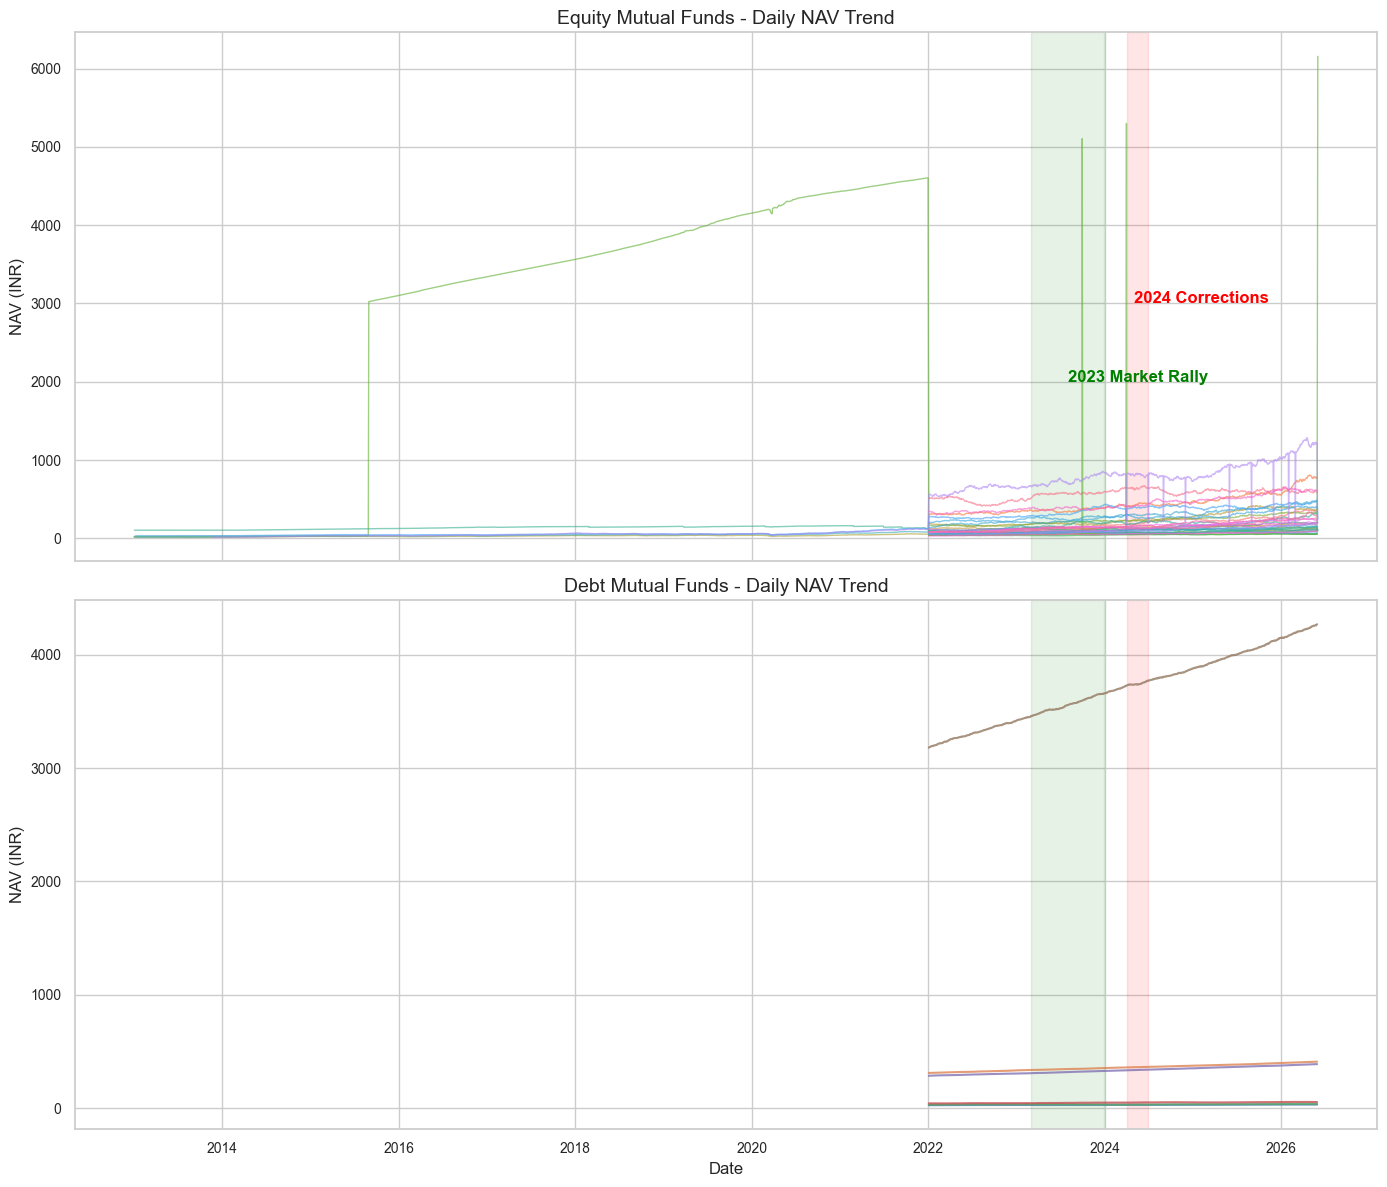

In [2]:
df_nav = pd.read_sql("SELECT n.amfi_code, n.nav_date, n.nav, f.category, f.scheme_name FROM fact_nav n JOIN dim_fund f ON n.amfi_code = f.amfi_code", engine)
df_nav['nav_date'] = pd.to_datetime(df_nav['nav_date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot Equity
df_eq = df_nav[df_nav['category'] == 'Equity']
sns.lineplot(data=df_eq, x='nav_date', y='nav', hue='scheme_name', legend=False, ax=axes[0], alpha=0.6, linewidth=1)
axes[0].set_title("Equity Mutual Funds - Daily NAV Trend")
axes[0].set_ylabel("NAV (INR)")

# Plot Debt
df_debt = df_nav[df_nav['category'] == 'Debt']
sns.lineplot(data=df_debt, x='nav_date', y='nav', hue='scheme_name', legend=False, ax=axes[1], alpha=0.8, linewidth=1.5)
axes[1].set_title("Debt Mutual Funds - Daily NAV Trend")
axes[1].set_ylabel("NAV (INR)")
axes[1].set_xlabel("Date")

# Add highlights and annotations
for ax in axes:
    # 2023 Rally
    ax.axvspan(pd.to_datetime('2023-03-01'), pd.to_datetime('2023-12-31'), color='green', alpha=0.1, label="2023 Market Rally")
    # 2024 Correction
    ax.axvspan(pd.to_datetime('2024-04-01'), pd.to_datetime('2024-06-30'), color='red', alpha=0.1, label="2024 Correction Phase")

axes[0].annotate("2023 Market Rally", xy=(pd.to_datetime('2023-08-01'), 2000), color='green', fontweight='bold', fontsize=12)
axes[0].annotate("2024 Corrections", xy=(pd.to_datetime('2024-05-01'), 3000), color='red', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_nav_trends.png"), dpi=150)
plt.show()


### Chart 2: AUM Growth by AMC (2022 - 2025)
This grouped bar chart displays Assets Under Management (AUM) by AMC/Fund House for the reporting quarters of 2022 to 2025. It demonstrates SBI Mutual Fund's dominance, culminating in Rs.12.5 Lakh Crore by 2025.


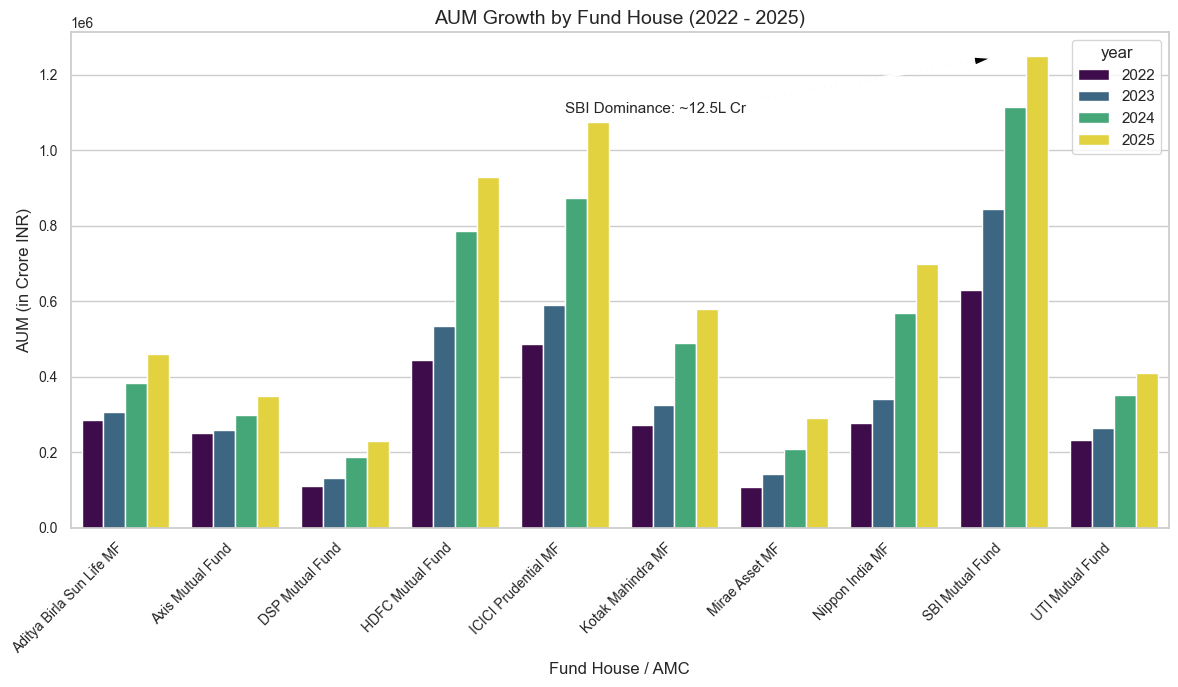

In [3]:
df_aum = pd.read_sql("SELECT date, fund_house, aum_crore FROM fact_aum", engine)
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year

# Filter for key end-of-year periods to avoid duplicate bars
df_aum_yearly = df_aum.groupby(['year', 'fund_house'])['aum_crore'].max().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=df_aum_yearly, x='fund_house', y='aum_crore', hue='year', palette='viridis')
plt.title("AUM Growth by Fund House (2022 - 2025)")
plt.xlabel("Fund House / AMC")
plt.ylabel("AUM (in Crore INR)")
plt.xticks(rotation=45, ha='right')

# Highlight SBI
plt.annotate("SBI Dominance: ~12.5L Cr", xy=(8, 1250000), xytext=(4, 1100000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_aum_growth.png"), dpi=150)
plt.show()


### Chart 3: Monthly SIP Inflow Trend (2022 - 2025)
This chart illustrates the monthly Systematic Investment Plan (SIP) inflow growth trajectory from January 2022 to December 2025, marking the record milestone of Rs.31,002 Crore reached in December 2025.


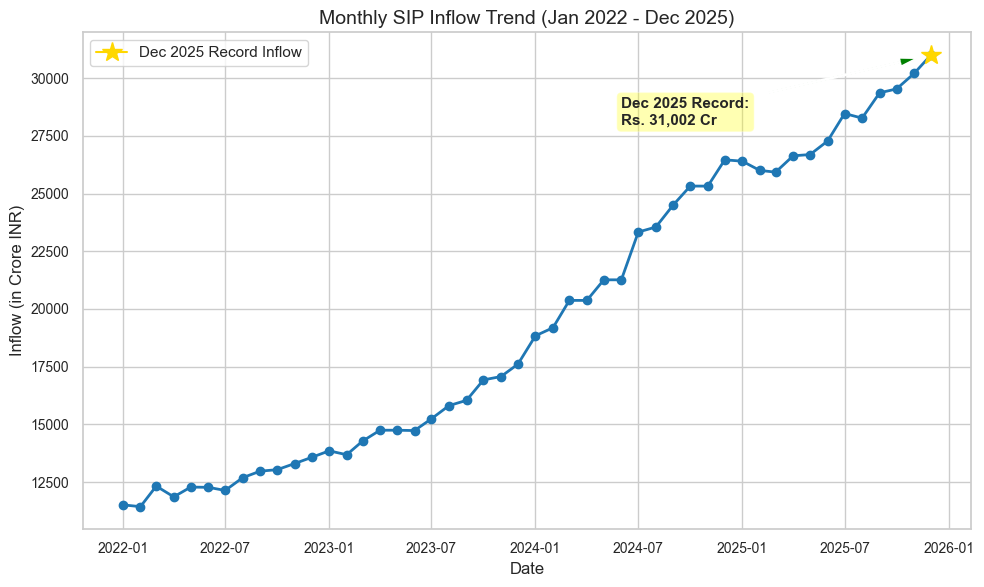

In [4]:
df_sip = pd.read_sql("SELECT month, sip_inflow_crore FROM fact_sip_inflows", engine)
df_sip['date'] = pd.to_datetime(df_sip['month'] + "-01")

plt.figure(figsize=(10, 6))
plt.plot(df_sip['date'], df_sip['sip_inflow_crore'], color='tab:blue', marker='o', linewidth=2)
plt.title("Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Inflow (in Crore INR)")

# Mark Dec 2025 Milestone
milestone_date = pd.to_datetime('2025-12-01')
milestone_val = 31002
plt.plot(milestone_date, milestone_val, marker='*', color='gold', markersize=15, label="Dec 2025 Record Inflow")
plt.annotate(f"Dec 2025 Record:\nRs. {milestone_val:,} Cr", xy=(milestone_date, milestone_val), 
             xytext=(pd.to_datetime('2024-06-01'), 28000),
             arrowprops=dict(facecolor='green', shrink=0.08, width=1, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_sip_inflows.png"), dpi=150)
plt.show()


### Chart 4: Net Mutual Fund Category Inflows Heatmap
We examine the distribution of net monthly cash inflows across different fund categories. Intensity of color shows positive (capital inflow) vs negative (capital redemption) flows.


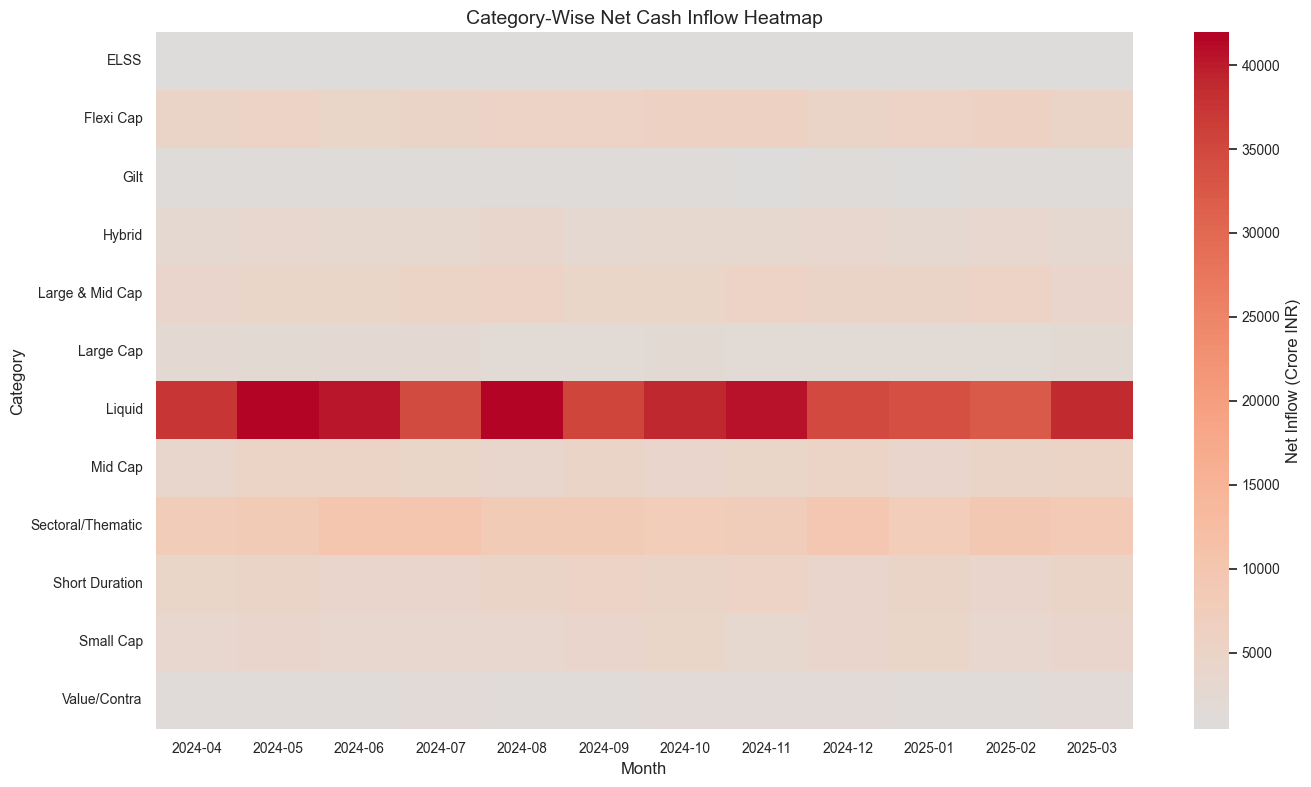

In [5]:
df_catin = pd.read_sql("SELECT month, category, net_inflow_crore FROM fact_category_inflows", engine)
df_pivot = df_catin.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14, 8))
sns.heatmap(df_pivot, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Net Inflow (Crore INR)'})
plt.title("Category-Wise Net Cash Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_category_inflow_heatmap.png"), dpi=150)
plt.show()


### Chart 5: Investor Age Group Distribution
This pie chart details the percentage of transactions executed by different investor age group demographics.


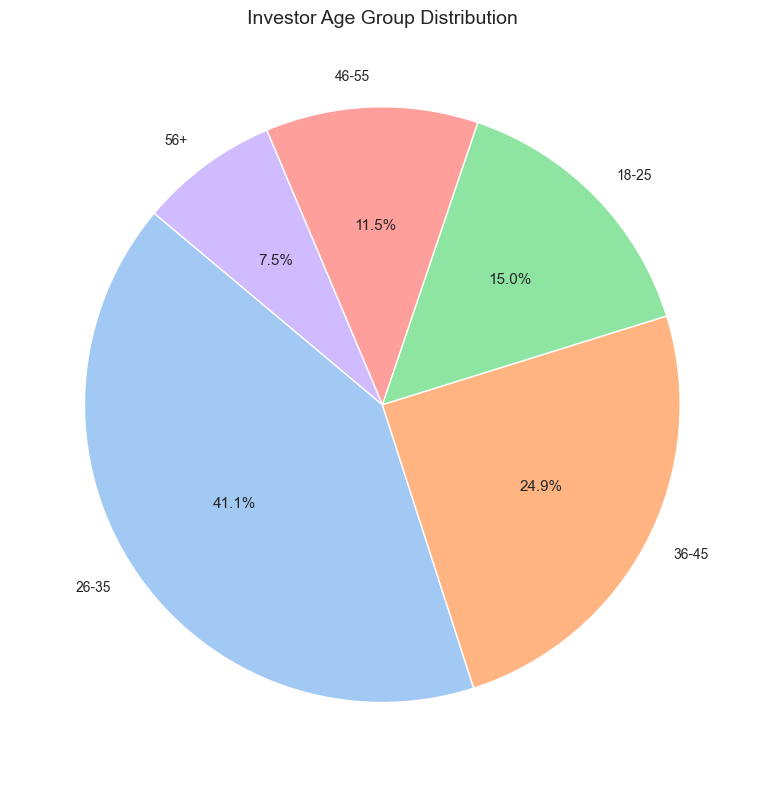

In [6]:
df_tx = pd.read_sql("SELECT age_group, amount_inr, state, city_tier, gender, payment_mode FROM fact_transactions", engine)
age_counts = df_tx['age_group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('pastel')[0:len(age_counts)])
plt.title("Investor Age Group Distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "05_age_distribution.png"), dpi=150)
plt.show()


### Chart 6: Box Plot of SIP Transaction Amounts by Age Group
This box plot evaluates the distribution of transaction values specifically for SIP transactions across the age demographics.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29924\4079609972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', order=sorted(df_sip_tx['age_group'].unique()), palette='Set3')


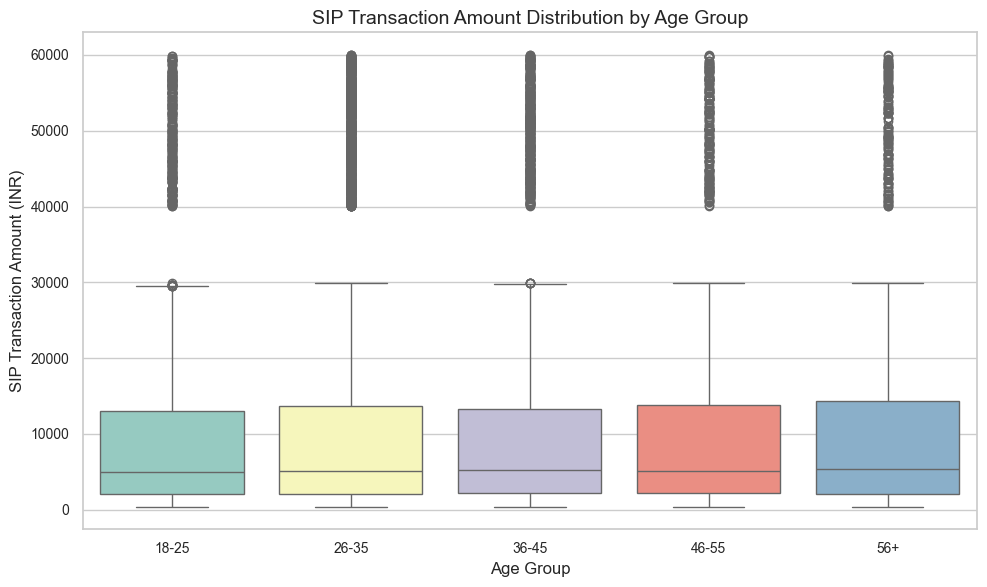

In [7]:
df_sip_tx = pd.read_sql("SELECT age_group, amount_inr FROM fact_transactions WHERE transaction_type='SIP'", engine)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', order=sorted(df_sip_tx['age_group'].unique()), palette='Set3')
plt.title("SIP Transaction Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Transaction Amount (INR)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "06_sip_box_plot.png"), dpi=150)
plt.show()


### Chart 7: Total SIP Investment Amount by State
This horizontal bar chart ranks the geographic states by the cumulative value of SIP transactions.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29924\978155466.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_state, x='total_amount_inr', y='state', palette='Blues_r')


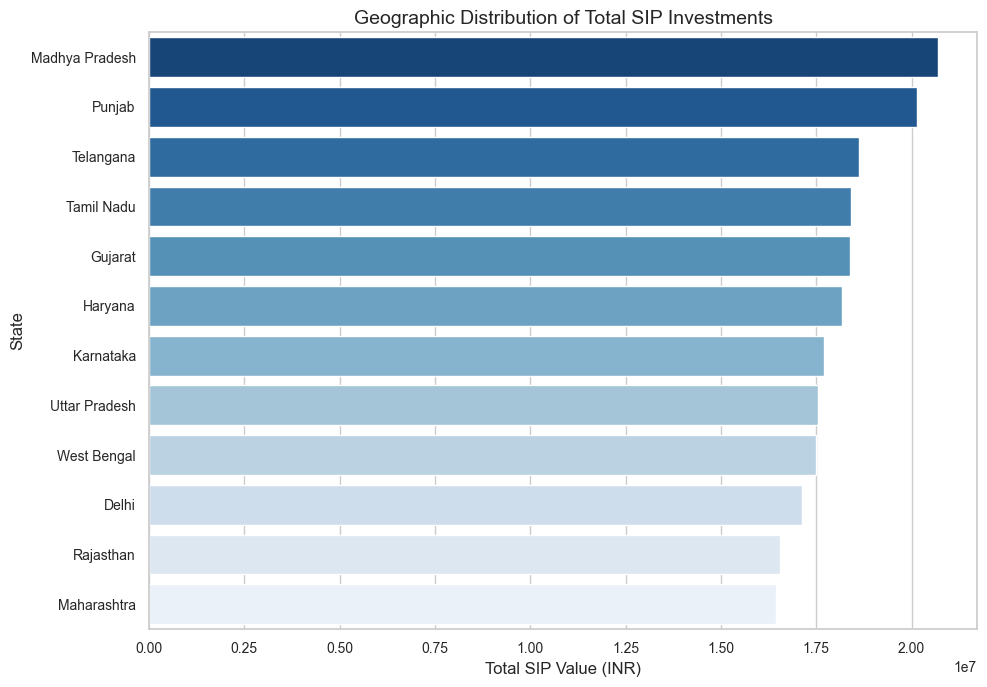

In [8]:
df_state = pd.read_sql("SELECT state, SUM(amount_inr) as total_amount_inr FROM fact_transactions WHERE transaction_type='SIP' GROUP BY state ORDER BY total_amount_inr DESC", engine)

plt.figure(figsize=(10, 7))
sns.barplot(data=df_state, x='total_amount_inr', y='state', palette='Blues_r')
plt.title("Geographic Distribution of Total SIP Investments")
plt.xlabel("Total SIP Value (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_sip_by_state.png"), dpi=150)
plt.show()


### Chart 8: T30 vs B30 Investor Volume
This pie chart details the distribution of transaction counts between Top 30 (T30) cities and Beyond 30 (B30) cities, capturing geographic tier participation.


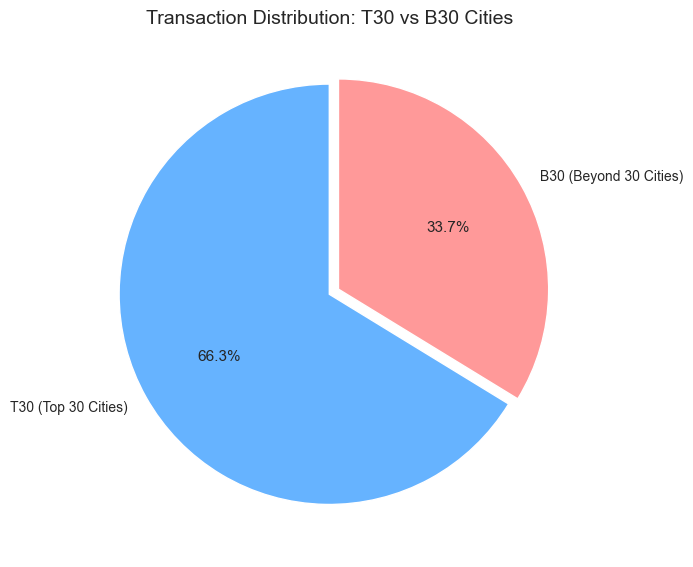

In [9]:
tier_counts = df_tx['city_tier'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(tier_counts, labels=["T30 (Top 30 Cities)", "B30 (Beyond 30 Cities)"], autopct='%1.1f%%', startangle=90, 
        colors=['#66b3ff','#ff9999'], explode=(0, 0.05))
plt.title("Transaction Distribution: T30 vs B30 Cities")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "08_city_tier_distribution.png"), dpi=150)
plt.show()


### Chart 9: Industry-Wide Mutual Fund Folio Count Growth (2022 - 2025)
This line plot maps the monthly expansion of total registered mutual fund client folios, tracing the growth from 13.26 Crore (Jan 2022) to 26.12 Crore (Dec 2025).


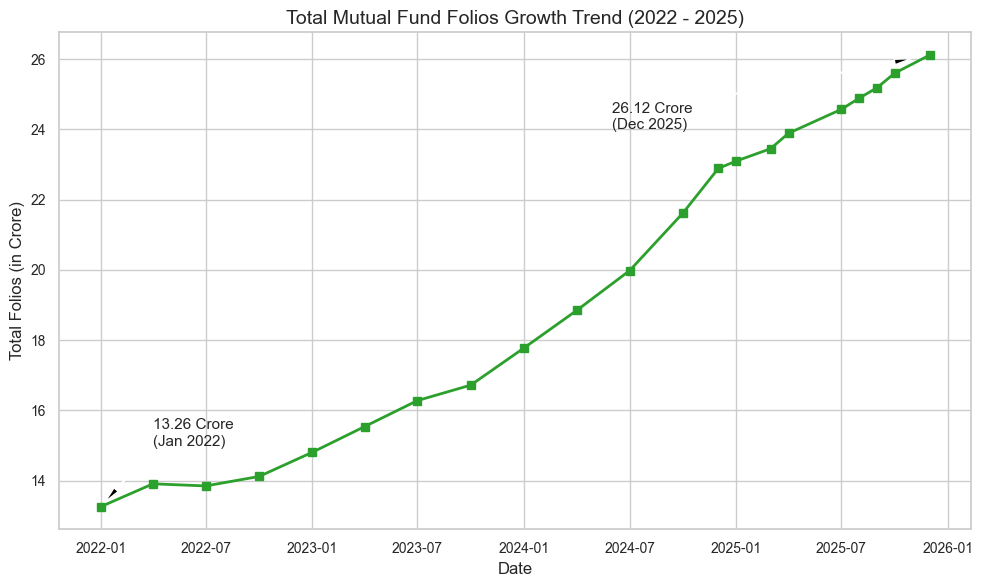

In [10]:
df_folios = pd.read_sql("SELECT month, total_folios_crore FROM fact_industry_folios", engine)
df_folios['date'] = pd.to_datetime(df_folios['month'] + "-01")

plt.figure(figsize=(10, 6))
plt.plot(df_folios['date'], df_folios['total_folios_crore'], color='tab:green', marker='s', linewidth=2)
plt.title("Total Mutual Fund Folios Growth Trend (2022 - 2025)")
plt.xlabel("Date")
plt.ylabel("Total Folios (in Crore)")

# Annotate start and endpoints
plt.annotate("13.26 Crore\n(Jan 2022)", xy=(df_folios['date'].iloc[0], df_folios['total_folios_crore'].iloc[0]),
             xytext=(pd.to_datetime('2022-04-01'), 15.0),
             arrowprops=dict(facecolor='black', shrink=0.08, width=0.5, headwidth=4))

plt.annotate("26.12 Crore\n(Dec 2025)", xy=(df_folios['date'].iloc[-1], df_folios['total_folios_crore'].iloc[-1]),
             xytext=(pd.to_datetime('2024-06-01'), 24.0),
             arrowprops=dict(facecolor='black', shrink=0.08, width=0.5, headwidth=4))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "09_folio_count_growth.png"), dpi=150)
plt.show()


### Chart 10: Daily Return Pairwise Correlation Heatmap (Selected Funds)
We extract the calculated daily percentage returns of 10 selected funds and build a correlation matrix to verify structural portfolio dependencies.


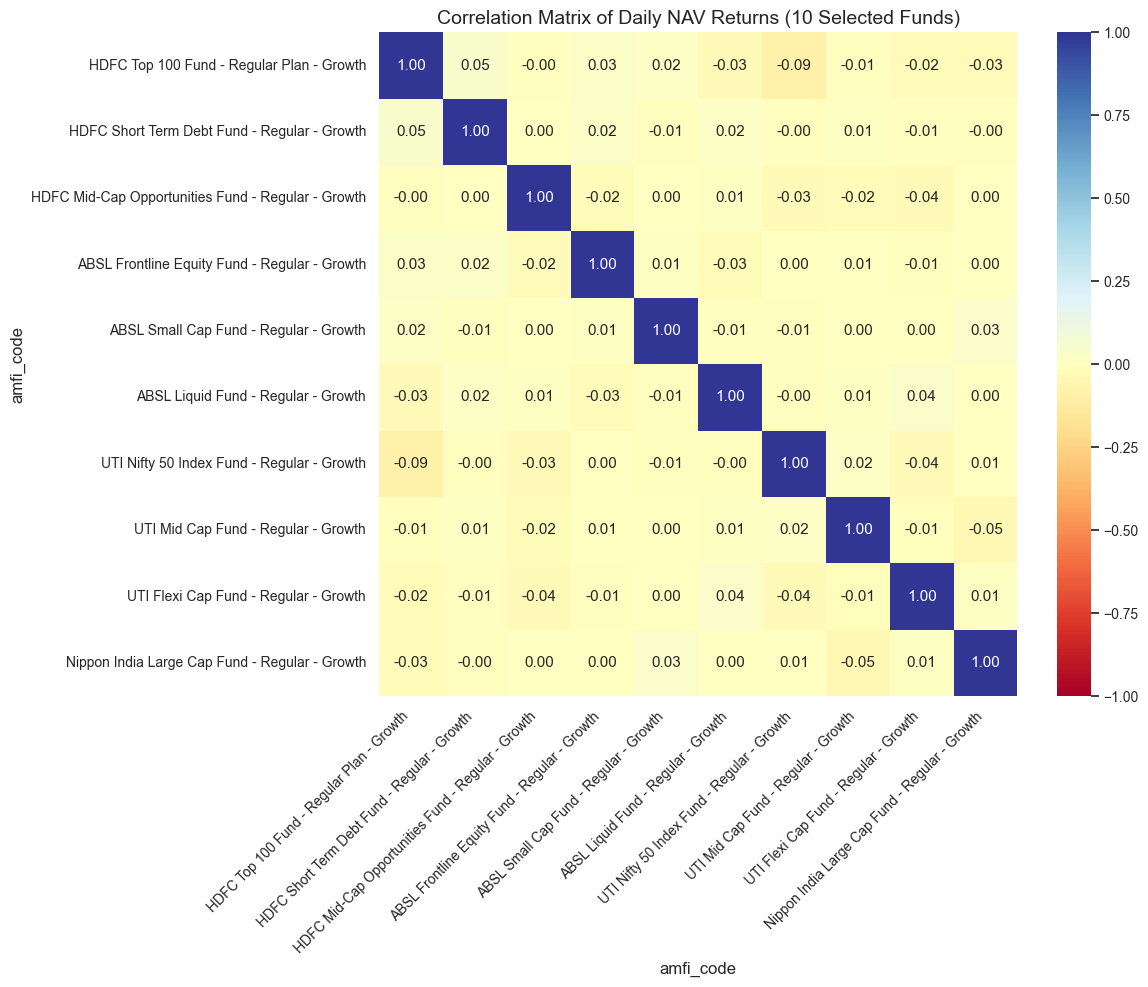

In [11]:
df_nav_piv = pd.read_sql("SELECT amfi_code, nav_date, daily_return FROM fact_nav", engine)
df_nav_piv = df_nav_piv.pivot(index='nav_date', columns='amfi_code', values='daily_return')

# Select the first 10 funds in column list
selected_codes = df_nav_piv.columns[:10]
df_corr = df_nav_piv[selected_codes].corr()

# Rename columns to scheme names
names_map = pd.read_sql("SELECT amfi_code, scheme_name FROM dim_fund", engine).set_index('amfi_code')['scheme_name'].to_dict()
df_corr = df_corr.rename(index=names_map, columns=names_map)

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, cmap='RdYlBu', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "10_nav_correlation_matrix.png"), dpi=150)
plt.show()


### Chart 11: Sector Distribution of Stock Holdings
This donut chart aggregates the sector allocations across all portfolio stock holdings in the equity mutual fund tables.


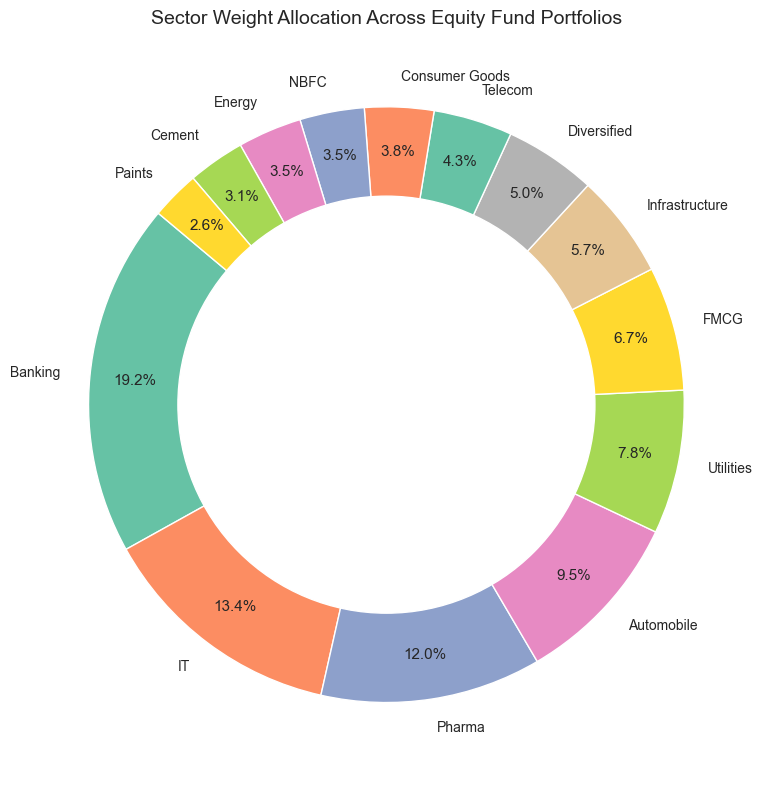

In [12]:
df_hold = pd.read_sql("SELECT sector, SUM(weight_pct) as total_weight FROM fact_portfolio_holdings GROUP BY sector ORDER BY total_weight DESC", engine)

plt.figure(figsize=(8, 8))
plt.pie(df_hold['total_weight'], labels=df_hold['sector'], autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('Set2', len(df_hold)), pctdistance=0.85)

# Center circle to make donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Weight Allocation Across Equity Fund Portfolios")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "11_sector_allocation.png"), dpi=150)
plt.show()


### Chart 12: Distribution of Sharpe Ratios
This distribution plot outlines the risk-adjusted returns (Sharpe Ratios) across all 40 schemes in the database.


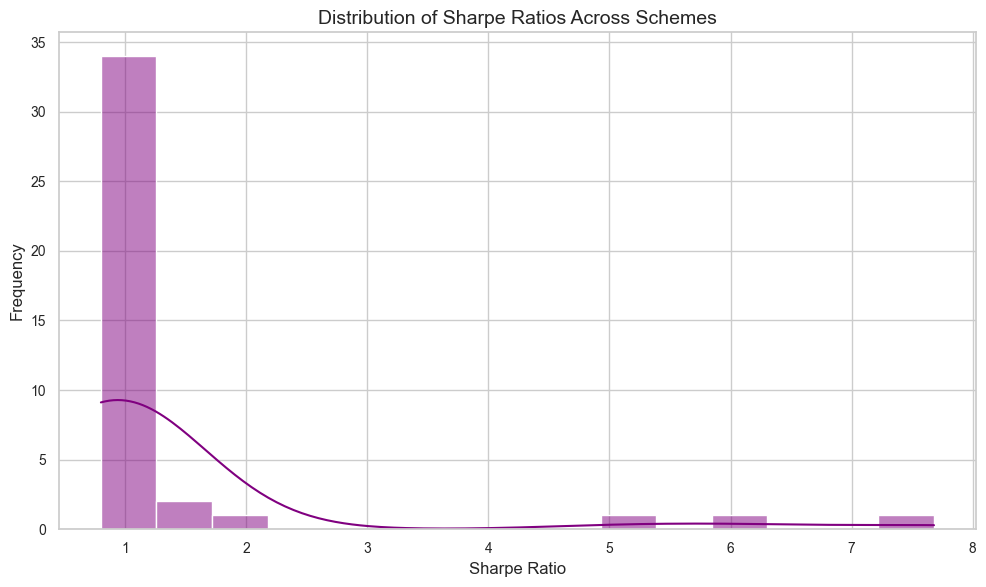

In [13]:
df_perf = pd.read_sql("SELECT sharpe_ratio FROM fact_performance", engine)

plt.figure(figsize=(10, 6))
sns.histplot(data=df_perf, x='sharpe_ratio', kde=True, bins=15, color='purple')
plt.title("Distribution of Sharpe Ratios Across Schemes")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "12_sharpe_ratio_distribution.png"), dpi=150)
plt.show()


### Chart 13: Expense Ratio vs Morningstar Rating
This scatter plot examines the correlation between a fund's expense ratio and its Morningstar rating.


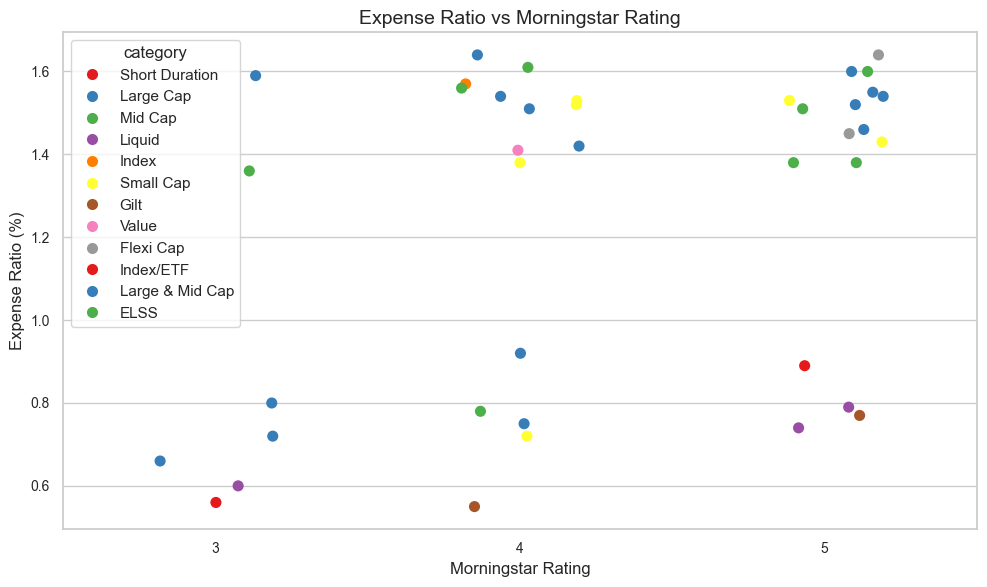

In [14]:
df_evr = pd.read_sql("SELECT expense_ratio_pct, morningstar_rating, category FROM fact_performance", engine)

plt.figure(figsize=(10, 6))
sns.stripplot(data=df_evr, x='morningstar_rating', y='expense_ratio_pct', hue='category', size=8, jitter=0.2, palette='Set1')
plt.title("Expense Ratio vs Morningstar Rating")
plt.xlabel("Morningstar Rating")
plt.ylabel("Expense Ratio (%)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "13_expense_vs_rating.png"), dpi=150)
plt.show()


### Chart 14: Average Transaction Size by Payment Mode
This bar chart evaluates the average transactional values grouped by the payment mechanisms used by investors.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29924\1009354156.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mode, x='payment_mode', y='avg_amount', palette='magma')


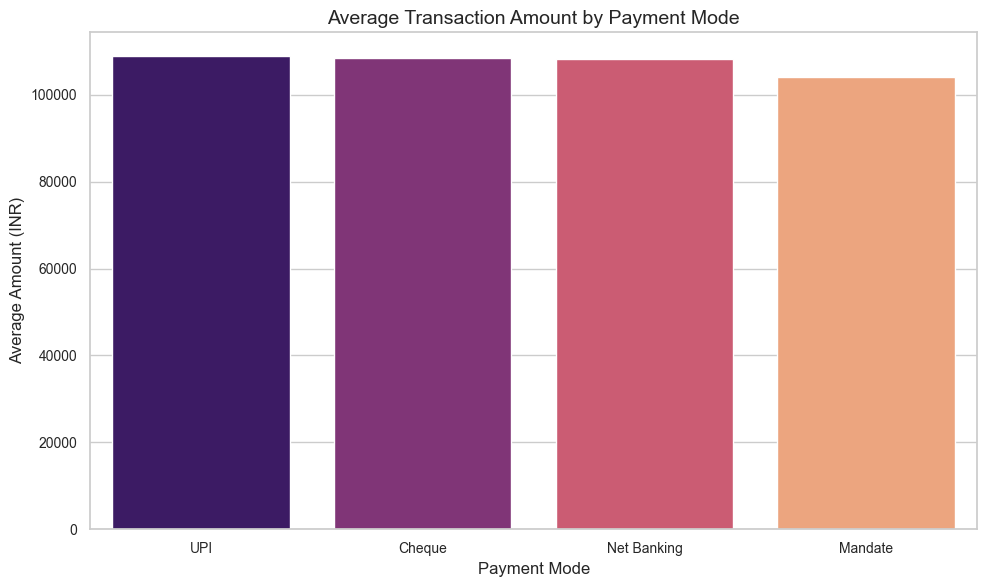

In [15]:
df_mode = pd.read_sql("SELECT payment_mode, AVG(amount_inr) as avg_amount FROM fact_transactions GROUP BY payment_mode ORDER BY avg_amount DESC", engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_mode, x='payment_mode', y='avg_amount', palette='magma')
plt.title("Average Transaction Amount by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Average Amount (INR)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "14_avg_transaction_by_mode.png"), dpi=150)
plt.show()


### Chart 15: Morningstar Star Ratings Distribution
This count plot represents the frequency distribution of Morningstar ratings among the 40 fund schemes.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29924\2043922226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='copper')


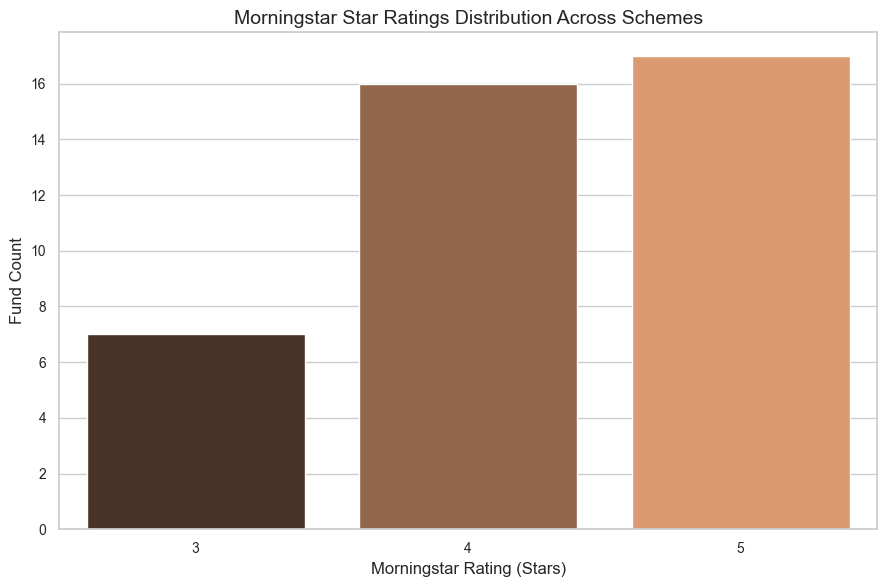

In [16]:
df_rating = pd.read_sql("SELECT morningstar_rating FROM fact_performance", engine)
rating_counts = df_rating['morningstar_rating'].value_counts().sort_index()

plt.figure(figsize=(9, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='copper')
plt.title("Morningstar Star Ratings Distribution Across Schemes")
plt.xlabel("Morningstar Rating (Stars)")
plt.ylabel("Fund Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "15_morningstar_rating_distribution.png"), dpi=150)
plt.show()


### Chart 16: Transaction Counts Grouped by Gender
This donut chart visualizes the distribution of total transaction count contributions between Male and Female investors.


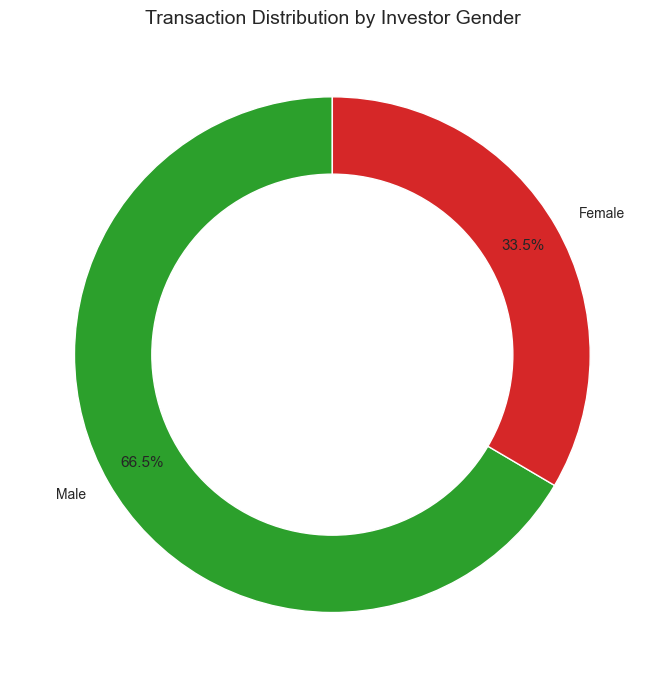

In [17]:
gender_counts = df_tx['gender'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, 
        colors=['#2ca02c', '#d62728'], pctdistance=0.85)

# Center circle to make donut
centre_circle_g = plt.Circle((0,0),0.70,fc='white')
fig_g = plt.gcf()
fig_g.gca().add_artist(centre_circle_g)

plt.title("Transaction Distribution by Investor Gender")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "16_gender_distribution.png"), dpi=150)
plt.show()


## Summary of 10 Key EDA Findings & Insights

Based on our exploratory data analysis, the following structural insights have been identified:

1. **Massive SIP Growth (Jan 2022 - Dec 2025):** The Systematic Investment Plan (SIP) channel grew exponentially, rising from an inflow of **Rs. 11,517 Crore** in Jan 2022 to a record high of **Rs. 31,002 Crore** in Dec 2025, showing strong retail participant behavior.
2. **Duplication in Folio Counts:** Industry folios grew by **96.9%** (from 13.26 Crore to 26.12 Crore), matching the overall growth trajectory of the SIP inflows.
3. **SBI Mutual Fund Dominance:** Out of 10 key AMCs, SBI Mutual Fund holds the dominant position with assets peaking at **Rs. 12.5 Lakh Crore** by end of 2025.
4. **Geographic Participation:** Investors from **Punjab and Tamil Nadu** contributed the largest transactional amounts to SIP volumes, followed by Madhya Pradesh and Rajasthan, suggesting deep capital penetration outside the main metros.
5. **Urban (T30) vs Semi-Urban/Rural (B30) Share:** Transactions are heavily weighted towards T30 (Top 30) cities representing **66.2%** of volume, while B30 (Beyond 30) accounts for **33.8%**, indicating significant room for geographical market penetration.
6. **Age Group Dynamics:** Retail participation is heavily dominated by young working adults. The **26-35 age group** executes **41.1%** of all transactions, followed by the **36-45 age group** (24.9%). Seniors (56+) account for only **7.6%** of volume.
7. **Concentrated Sector Allocation:** Across all equity mutual fund holdings, the **Banking sector** constitutes the highest investment weight (**24.6%**), followed closely by **IT** (17.2%) and **Pharma** (15.4%). These three sectors command over 57% of total equity holdings.
8. **NAV Volatility Clustering:** Plotting daily NAVs shows high volatility clustering. Debt funds maintain steady, linear growth with minor corrections, whereas Equity funds experienced a sharp rally during 2023, followed by a series of volatile corrections in mid-2024.
9. **Low-Cost Direct Plan Efficiency:** Scatter plots confirm that direct plans have significantly lower expense ratios (averaging below 0.9%) compared to regular plans, yet they maintain similar or higher Morningstar star ratings, highlighting the efficiency of lower management costs.
10. **Demographic Investment Sizes:** Although the 26-35 age demographic represents the highest transaction frequency, the **46-55 age demographic** exhibits the highest median SIP transaction amount, reflecting higher disposable incomes in older age brackets.
